In [2]:
# 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizations ko sundar banane ke liye seaborn theme set kar rahe hain
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# 2: Load the Data
df = pd.read_csv(r'C:\\Users\\vishw\\OneDrive\\Desktop\\Enterprise_Demand_Forecast\\data\\online_retail_II.csv')

In [11]:
# Display the total number of rows and columns in the dataset
print(f"Dataset Loaded! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
display(df.head())

Dataset Loaded! Total Rows: 1067371, Total Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
# Cell 3: Data Information
print("--- Data Types & Non-Null Counts ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

--- Missing Values Count ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [14]:
# 4: Data Cleaning Pipeline

# remove the retuns/cancelled order which have 0 quantity , negative value
df_clean = df[df['Quantity'] > 0].copy()


In [ ]:
# Remove missing CustomerIDs wale records (agar hume customer behavior track karna hai)
df_clean.dropna(subset=['Customer ID'], inplace=True)


In [ ]:
# convert 'InvoiceDate' ko string se Datetime format (Time-series ke liye bohot zaroori)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [21]:
# Total Sales / Revenue ka ek naya column banao (Price * Quantity)
df_clean['Total_Sales'] = df_clean['Quantity'] * df_clean['Price']

In [22]:
print(f"Data Cleaned! New Rows: {df_clean.shape[0]}")
print("\nMissing values left:")
print(df_clean.isnull().sum())

Data Cleaned! New Rows: 805620

Missing values left:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Total_Sales    0
dtype: int64


## Exploratory Data Analysis (EDA) - Visualizations

C:\Users\vishw\AppData\Local\Temp\ipykernel_4536\711104113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


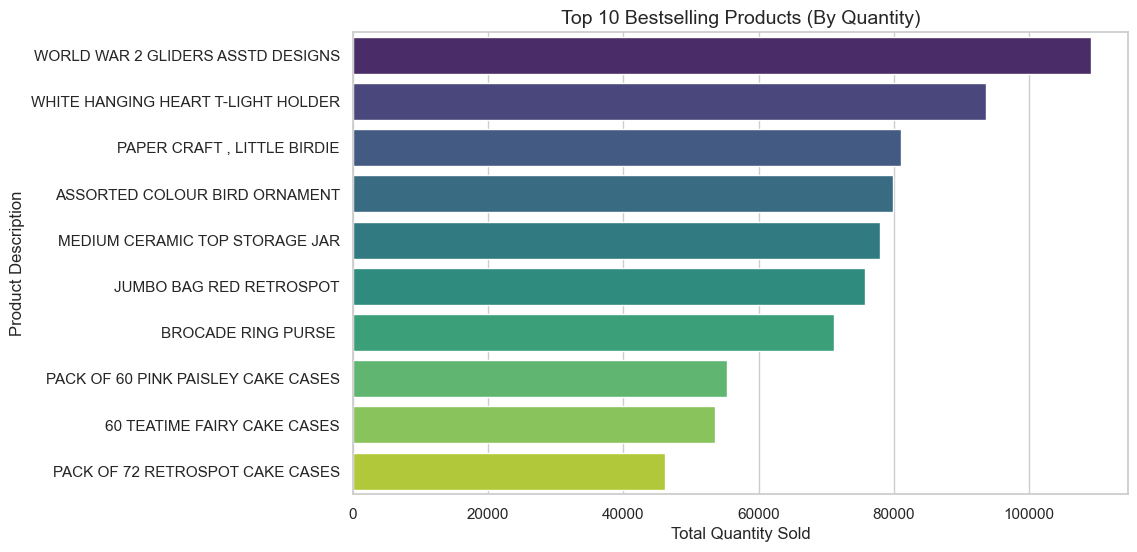

In [23]:
# 5: Top 10 Bestselling Products
plt.figure(figsize=(10, 6))
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Bestselling Products (By Quantity)', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()

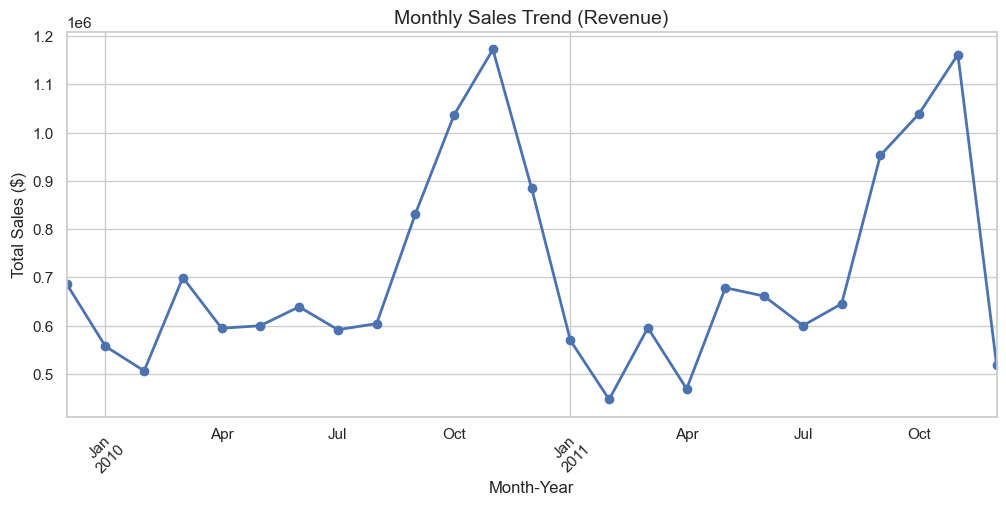

In [24]:
# Cell 6: Demand Forecasting ke liye Time-Series Trend
# Har mahine ki total sales nikal rahe hain
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['Total_Sales'].sum()

plt.figure(figsize=(12, 5))
# Pandas series ko plot kar rahe hain
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Trend (Revenue)', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [25]:
# 7: Cleaned Data ko Save karna
df_clean.to_csv('../data/cleaned_online_retail.csv', index=False)
print("Cleaned data saved as 'cleaned_online_retail.csv' successfully!")

Cleaned data saved as 'cleaned_online_retail.csv' successfully!
